In [1]:
#train pipleline\
# sum ampl/ count



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.ndimage import gaussian_filter

In [3]:
N_BINS = 40

SIGMA = 1.0

EPS = 1e-10

SKIP_TIMESTEPS = 50

GAUSSIAN_KERNEL = (5, 5)


In [4]:
def get_input_data(
    pkl_path,
    layer_name,
):
    """
    Load the 2D trajectory dataset.

    Returns
    -------
    ground_truth : (n_traj, T, 2)

    prediction : (n_traj, T, 2)

    positions : (n_traj, T, 2)

    activations : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])

    prediction = np.asarray(data["prediction"])

    activations = np.asarray(data[layer_name])

    positions = prediction.copy()

    if SKIP_TIMESTEPS > 0:

        ground_truth = ground_truth[:, SKIP_TIMESTEPS:, :]

        prediction = prediction[:, SKIP_TIMESTEPS:, :]

        positions = positions[:, SKIP_TIMESTEPS:, :]

        activations = activations[:, SKIP_TIMESTEPS:, :]

    return (
        ground_truth,
        prediction,
        positions,
        activations,
    )

In [5]:
def get_arena_bounds(positions):
    """
    Compute global arena bounds across all trajectories.

    Parameters
    ----------
    positions : ndarray
        Shape (n_traj, T, 2)

    Returns
    -------
    bounds : tuple
        (xmin, xmax, ymin, ymax)
    """

    xmin = np.min(positions[:, :, 0])
    xmax = np.max(positions[:, :, 0])

    ymin = np.min(positions[:, :, 1])
    ymax = np.max(positions[:, :, 1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [6]:
def get_arena_bounds(positions_list):
    """
    Compute global arena bounds shared across every trajectory.
    """

    all_positions = np.concatenate(positions_list, axis=0)

    xmin = np.min(all_positions[:,0])
    xmax = np.max(all_positions[:,0])

    ymin = np.min(all_positions[:,1])
    ymax = np.max(all_positions[:,1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [7]:
def bin_positions(
    positions,
    bins=N_BINS,
    bounds=None,
):
    """
    Assign every (x, y) position sample to a spatial bin.

    Parameters
    ----------
    positions : ndarray
        Shape (T, 2)

    bins : int
        Number of bins along each dimension.

    bounds : tuple
        (xmin, xmax, ymin, ymax)

    Returns
    -------
    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    x_edges : ndarray
        Bin edges along x.

    y_edges : ndarray
        Bin edges along y.
    """

    xmin, xmax, ymin, ymax = bounds

    x_edges = np.linspace(xmin, xmax, bins + 1)
    y_edges = np.linspace(ymin, ymax, bins + 1)

    x_bin = np.digitize(
        positions[:, 0],
        x_edges,
    ) - 1

    y_bin = np.digitize(
        positions[:, 1],
        y_edges,
    ) - 1

    # Keep indices inside the grid
    x_bin = np.clip(x_bin, 0, bins - 1)
    y_bin = np.clip(y_bin, 0, bins - 1)

    return x_bin, y_bin, x_edges, y_edges

In [8]:
def compute_occupancy_maps(
    x_bin,
    y_bin,
    bins=N_BINS,
):
    """
    Compute 2D occupancy maps.

    Parameters
    ----------
    x_bin : ndarray
    y_bin : ndarray

    Returns
    -------
    count_occupancy : (bins,bins)

    probability_occupancy : (bins,bins)
    """

    count_occupancy = np.zeros((bins, bins), dtype=float)

    # Count visits
    for xb, yb in zip(x_bin, y_bin):
        count_occupancy[yb, xb] += 1

    total = np.sum(count_occupancy)

    if total > 0:
        probability_occupancy = count_occupancy / total
    else:
        probability_occupancy = np.zeros_like(count_occupancy)

    return count_occupancy, probability_occupancy

In [9]:
def compute_activity_maps(
    activity,
    x_bin,
    y_bin,
    bins=N_BINS,
):
    """
    Compute 2D activity maps for ONE neuron.

    Parameters
    ----------
    activity : ndarray
        Shape (T,)

    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    Returns
    -------
    amplitude_activity : (bins, bins)

    real_activity : (bins, bins)
    """

    amplitude = np.abs(activity)

    real = np.real(activity)

    amplitude_activity = np.zeros((bins, bins), dtype=float)

    real_activity = np.zeros((bins, bins), dtype=float)

    for a, r, xb, yb in zip(
        amplitude,
        real,
        x_bin,
        y_bin,
    ):

        amplitude_activity[yb, xb] += a

        real_activity[yb, xb] += r

    return amplitude_activity

In [10]:
def compute_firing_rate_map(
    activity_map,
    occupancy_map,
    eps=EPS,
):
    """
    Compute firing-rate map.

    Works for both 1D and 2D arrays.

    Parameters
    ----------
    activity_map : ndarray
    occupancy_map : ndarray

    Returns
    -------
    firing_rate_map : ndarray
    """

    firing_rate = np.divide(
        activity_map,
        occupancy_map + eps,
    )

    firing_rate[occupancy_map == 0] = 0

    return firing_rate

In [11]:
from scipy.signal import convolve2d


def matlab_style_gauss2D(shape=(5, 5), sigma=1.0):
    """
    2D Gaussian mask equivalent to MATLAB's

        fspecial('gaussian', shape, sigma)

    Parameters
    ----------
    shape : tuple
        Size of the Gaussian kernel.

    sigma : float
        Standard deviation of the Gaussian.

    Returns
    -------
    h : ndarray
        Normalized Gaussian kernel.
    """

    m, n = [(ss - 1.) / 2. for ss in shape]

    y, x = np.ogrid[-m:m+1, -n:n+1]

    h = np.exp(-(x*x + y*y) / (2.0 * sigma * sigma))

    h[h < np.finfo(h.dtype).eps * h.max()] = 0

    if h.sum() != 0:
        h /= h.sum()

    return h


def smooth_firing_rate_map(
    firing_rate_map,
    sigma=SIGMA,
    kernel_shape=GAUSSIAN_KERNEL,
):
    """
    Smooth a firing-rate map using a MATLAB-style Gaussian kernel.

    Parameters
    ----------
    firing_rate_map : ndarray
        2D firing-rate map.

    sigma : float
        Gaussian standard deviation.

    kernel_shape : tuple
        Kernel size used by MATLAB's fspecial.
    """

    kernel = matlab_style_gauss2D(
        shape=kernel_shape,
        sigma=sigma,
    )

    smoothed = convolve2d(
        firing_rate_map,
        kernel,
        mode="same",
        boundary="symm",
    )

    return smoothed

In [12]:
def spatial_information(rate_map, occupancy_map):
    """
    Spatial Information (bits/spike)

    Parameters
    ----------
    rate_map : ndarray
        Smoothed firing-rate map

    occupancy_map : ndarray
        Count or probability occupancy
    """

    occ = occupancy_map.astype(float)
    occ = occ / occ.sum()

    valid = (
        (~np.isnan(rate_map))
        & (occ > 0)
        & (rate_map > 0)
    )

    if np.sum(valid) == 0:
        return np.nan

    p = occ[valid]
    r = rate_map[valid]

    r_bar = np.sum(p * r)

    if r_bar <= EPS:
        return np.nan

    ratio = r / r_bar

    return np.sum(
        p * ratio * np.log2(ratio)
    )

In [13]:
def sparsity(rate_map, occupancy_map):
    """
    Population sparsity
    """

    occ = occupancy_map.astype(float)
    occ = occ / occ.sum()

    valid = (
        (~np.isnan(rate_map))
        & (occ > 0)
    )

    if np.sum(valid) == 0:
        return np.nan

    p = occ[valid]
    r = rate_map[valid]

    mean_r = np.sum(p * r)
    mean_r2 = np.sum(p * r**2)

    if mean_r2 <= EPS:
        return np.nan

    return (mean_r**2) / mean_r2

In [14]:
def evaluate_place_cell(rate_map, occupancy_map):
    """
    Compute place-cell metrics from a raw firing-rate map.
    """

    return {
        "Spatial Information": spatial_information(
            rate_map,
            occupancy_map,
        ),
        "Sparsity": sparsity(
            rate_map,
            occupancy_map,
        ),
    }

In [15]:
def compute_neuron_grid_score(
    positions,
    activity,
    bounds,
    bins=N_BINS,
    fixed_radius=None,
):
    """
    Compute the complete grid-cell pipeline for one neuron.

    Parameters
    ----------
    fixed_radius : float or None
        If provided, use this radius instead of estimating one.
        Useful for shuffle analysis.
    """

    # --------------------------------------------------
    # Bin positions
    # --------------------------------------------------

    x_bin, y_bin, _, _ = bin_positions(
        positions,
        bins=bins,
        bounds=bounds,
    )

    count_occ, _ = compute_occupancy_maps(
        x_bin,
        y_bin,
        bins=bins,
    )

    # --------------------------------------------------
    # Activity map
    # --------------------------------------------------

    amp_activity, _ = compute_activity_maps(
        activity,
        x_bin,
        y_bin,
        bins=bins,
    )

    # --------------------------------------------------
    # Rate map
    # --------------------------------------------------

    rate_map = compute_firing_rate_map(
        amp_activity,
        count_occ,
    )

    rate_map = smooth_firing_rate_map(
        rate_map,
    )

    # --------------------------------------------------
    # Spatial autocorrelation
    # --------------------------------------------------

    autocorr = spatial_autocorrelation(
        rate_map,
    )

    # --------------------------------------------------
    # Peak detection
    # --------------------------------------------------

    peaks = detect_autocorr_peaks(
        autocorr,
    )

    peaks = merge_close_peaks(
        peaks,
        min_distance=6,
    )

    if len(peaks) == 0:
        return None

    centre = centre_peak(
        peaks,
        autocorr.shape,
    )

    # --------------------------------------------------
    # Ring radius
    # --------------------------------------------------

    if fixed_radius is None:

        radius = first_ring_radius(
            peaks,
            centre,
        )

    else:

        radius = fixed_radius

    if radius is None:
        return None

    # --------------------------------------------------
    # Grid score
    # --------------------------------------------------

    grid_score, correlations = compute_grid_score(
        autocorr,
        inner_radius=0.5 * radius,
        outer_radius=1.5 * radius,
    )

    return {

        "grid_score": grid_score,

        "correlations": correlations,

        "rate_map": rate_map,

        "autocorr": autocorr,

        "radius": radius,

        "centre": centre,

        "peaks": peaks,

    }

In [16]:
def centre_peak(
    peaks,
    shape,
):
    """
    Find centroid closest to image centre.
    """

    centre = np.array(shape) / 2

    distances = np.linalg.norm(
        peaks - centre,
        axis=1,
    )

    return peaks[np.argmin(distances)]


def peak_distances(
    peaks,
    centre,
):
    """
    Euclidean distance from centre to every peak.
    """

    return np.linalg.norm(
        peaks - centre,
        axis=1,
    )


def first_ring_radius(
    peaks,
    centre,
    min_radius=10,
):
    """
    Estimate the radius of the first ring of peaks.
    """

    distances = np.linalg.norm(
        peaks - centre,
        axis=1,
    )

    # Ignore centre peak
    distances = distances[
        distances > min_radius
    ]

    if len(distances) < 6:
        return None

    # Sort by distance
    distances = np.sort(distances)

    # First six surrounding peaks
    first_ring = distances[:6]

    # Remove obvious outliers
    median = np.median(first_ring)

    first_ring = first_ring[
        np.abs(first_ring - median) < 8
    ]

    if len(first_ring) == 0:
        return None

    return np.median(first_ring)

In [17]:
def merge_close_peaks(
    peaks,
    min_distance=6,
):
    """
    Merge peaks that are very close together.

    Parameters
    ----------
    peaks : ndarray (N,2)

    min_distance : float
        Peaks closer than this are merged.

    Returns
    -------
    merged_peaks
    """

    if len(peaks) == 0:
        return peaks

    remaining = peaks.tolist()
    merged = []

    while len(remaining):

        current = np.array(remaining.pop(0))

        cluster = [current]

        keep = []

        for p in remaining:

            p = np.array(p)

            if np.linalg.norm(
                current - p
            ) < min_distance:

                cluster.append(p)

            else:

                keep.append(p)

        remaining = keep

        merged.append(
            np.mean(cluster, axis=0)
        )

    return np.array(merged)

In [18]:
def evaluate_place_cell(
    rate_map,
    occupancy_map,
):
    """
    Compute place-cell metrics for one firing-rate map.

    Parameters
    ----------
    rate_map : ndarray
        Smoothed firing-rate map.

    occupancy_map : ndarray
        Count or probability occupancy map.

    Returns
    -------
    metrics : dict
        Spatial Information and Sparsity.
    """

    return {
        "SI": spatial_information(
            rate_map,
            occupancy_map,
        ),
        "Sparsity": sparsity(
            rate_map,
            occupancy_map,
        ),
    }

In [19]:
import numpy as np


def point_correlation(
    rate_map,
    row_shift,
    col_shift,
):
    """
    Fast Pearson correlation between a rate map
    and a shifted copy.
    """

    rows, cols = rate_map.shape

    r1_start = max(0, row_shift)
    r1_end   = min(rows, rows + row_shift)

    r2_start = max(0, -row_shift)
    r2_end   = min(rows, rows - row_shift)

    c1_start = max(0, col_shift)
    c1_end   = min(cols, cols + col_shift)

    c2_start = max(0, -col_shift)
    c2_end   = min(cols, cols - col_shift)

    x = rate_map[
        r1_start:r1_end,
        c1_start:c1_end,
    ]

    y = rate_map[
        r2_start:r2_end,
        c2_start:c2_end,
    ]

    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 20:
        return np.nan

    x = x[valid]
    y = y[valid]

    x = x - x.mean()
    y = y - y.mean()

    denom = np.sqrt(
        np.sum(x*x) *
        np.sum(y*y)
    )

    if denom == 0:
        return np.nan

    return np.sum(x*y) / denom


def spatial_autocorrelation(rate_map):

    bins = rate_map.shape[0]

    autocorr = np.empty(
        (2*bins-1,2*bins-1),
        dtype=np.float32,
    )

    shifts = np.arange(
        -(bins-1),
        bins,
        dtype=np.int32,
    )

    for i,row_shift in enumerate(shifts):

        for j,col_shift in enumerate(shifts):

            autocorr[i,j] = point_correlation(
                rate_map,
                row_shift,
                col_shift,
            )

    return autocorr

In [20]:
from scipy.ndimage import maximum_filter

def detect_autocorr_peaks(
    autocorr,
    threshold=0.10,
    neighbourhood=5,
):
    """
    Detect local maxima in the autocorrelogram.
    """

    local_max = (
        autocorr ==
        maximum_filter(
            autocorr,
            size=neighbourhood,
        )
    )

    local_max &= autocorr > threshold

    peaks = np.argwhere(local_max)

    return peaks.astype(float)

In [21]:
def circular_shuffle(
    activity,
    min_shift=20,
):
    """
    Circularly shift a neuron's activity.

    Parameters
    ----------
    activity : (T,)

    min_shift : int
        Minimum shift to avoid trivial shuffles.

    Returns
    -------
    shuffled_activity
    """

    T = len(activity)

    shift = np.random.randint(
        min_shift,
        T - min_shift,
    )

    shuffled = np.roll(
        activity,
        shift,
    )

    return shuffled

In [22]:
import numpy as np


def compute_grid_score(
    autocorr,
    inner_radius,
    outer_radius,
):
    """
    Calculate grid score from a spatial autocorrelation map.

    Grid score is:

        mean(correlation at 60, 120 degrees)
        -
        mean(correlation at 30, 90, 150 degrees)

    Parameters
    ----------
    autocorr : 2D numpy array
        Spatial autocorrelation map.

    inner_radius : float
        Inner radius of the annulus around the centre.

    outer_radius : float
        Outer radius of the annulus.

    Returns
    -------
    grid_score : float
        Hexagonal/grid-like symmetry score.

    correlations : dict
        Correlations for each rotation angle.
    """

    # --------------------------------------------------------
    # Centre of autocorrelation map
    # --------------------------------------------------------

    centre_y = (autocorr.shape[0] - 1) / 2
    centre_x = (autocorr.shape[1] - 1) / 2

    y, x = np.indices(autocorr.shape)

    distance = np.sqrt(
        (x - centre_x) ** 2 +
        (y - centre_y) ** 2
    )

    # --------------------------------------------------------
    # Build annulus
    # --------------------------------------------------------

    annulus_mask = (
        (distance >= inner_radius) &
        (distance <= outer_radius)
    )

    # Extract annulus
    annulus = np.where(
        annulus_mask,
        autocorr,
        np.nan
    )

    # --------------------------------------------------------
    # Rotation correlation
    # --------------------------------------------------------

    def rotate_map_approx(angle):

        # Convert angle to radians
        theta = np.deg2rad(angle)

        # Coordinates relative to centre
        dx = x - centre_x
        dy = y - centre_y

        # Rotate coordinates
        xr = (
            np.cos(theta) * dx
            - np.sin(theta) * dy
        ) + centre_x

        yr = (
            np.sin(theta) * dx
            + np.cos(theta) * dy
        ) + centre_y

        # Nearest-neighbour sampling
        xr = np.rint(xr).astype(int)
        yr = np.rint(yr).astype(int)

        valid = (
            (xr >= 0) &
            (xr < autocorr.shape[1]) &
            (yr >= 0) &
            (yr < autocorr.shape[0])
        )

        rotated = np.full_like(
            autocorr,
            np.nan,
            dtype=float
        )

        rotated[valid] = autocorr[
            yr[valid],
            xr[valid]
        ]

        return rotated

    # --------------------------------------------------------
    # Calculate correlations
    # --------------------------------------------------------

    angles = [30, 60, 90, 120, 150]

    correlations = {}

    original_values = autocorr[annulus_mask]

    for angle in angles:

        rotated = rotate_map_approx(angle)

        rotated_values = rotated[annulus_mask]

        # Remove invalid values
        valid = (
            np.isfinite(original_values) &
            np.isfinite(rotated_values)
        )

        if np.sum(valid) < 3:

            correlations[angle] = np.nan

        else:

            correlations[angle] = np.corrcoef(
                original_values[valid],
                rotated_values[valid]
            )[0, 1]

    # --------------------------------------------------------
    # Grid score
    # --------------------------------------------------------

    six_fold = np.nanmean([
        correlations[60],
        correlations[120],
    ])

    three_fold = np.nanmean([
        correlations[30],
        correlations[90],
        correlations[150],
    ])

    grid_score = six_fold - three_fold

    return grid_score, correlations

#main


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD POSITIONS
# ============================================================

trajectory_results_path = (
    r"C:\Users\ALL AtoZ\Desktop\2d_hippocampal_cells"
    r"\2D-traj-results-training.pkl"
)

# We can load d1 just to get the positions.
# Positions are shared across the layers.
ground_truth, prediction, positions, activations = get_input_data(
    trajectory_results_path,
    "d4",
)

print("Positions shape:", positions.shape)

# ============================================================
# SETTINGS
# ============================================================

n_trajectories_to_select = 10

# Use the same binning resolution as your grid-cell analysis
n_bins = N_BINS

bounds = get_arena_bounds(positions)

print("Bounds:", bounds)
print("Number of bins:", n_bins)

# ============================================================
# CALCULATE OCCUPANCY BINS FOR EVERY TRAJECTORY
# ============================================================

trajectory_bin_sets = []

for trajectory in range(positions.shape[0]):

    x_bin, y_bin, x_edges, y_edges = bin_positions(
        positions[trajectory],
        bins=n_bins,
        bounds=bounds,
    )

    # Convert (x,y) bins into a single integer ID
    bin_ids = (
        x_bin.astype(int) * n_bins
        + y_bin.astype(int)
    )

    # Unique spatial bins visited by this trajectory
    unique_bins = np.unique(bin_ids)

    trajectory_bin_sets.append(
        set(unique_bins)
    )

# ============================================================
# GREEDY COVERAGE SELECTION
# ============================================================

selected_trajectories = []
covered_bins = set()

remaining = set(range(len(trajectory_bin_sets)))

for i in range(n_trajectories_to_select):

    best_trajectory = None
    best_new_coverage = -1

    for trajectory in remaining:

        new_bins = (
            trajectory_bin_sets[trajectory]
            - covered_bins
        )

        new_coverage = len(new_bins)

        if new_coverage > best_new_coverage:

            best_new_coverage = new_coverage
            best_trajectory = trajectory

    selected_trajectories.append(
        best_trajectory
    )

    covered_bins.update(
        trajectory_bin_sets[best_trajectory]
    )

    remaining.remove(
        best_trajectory
    )

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("SELECTED TRAJECTORIES")
print("=" * 70)

for i, trajectory in enumerate(
    selected_trajectories,
    start=1
):

    print(
        f"{i:2d}. Trajectory {trajectory:3d} | "
        f"Unique bins = "
        f"{len(trajectory_bin_sets[trajectory])}"
    )

print(
    "\nTotal unique spatial bins covered:",
    len(covered_bins),
    "/",
    n_bins * n_bins
)

Positions shape: (500, 450, 2)
Bounds: (0.027809273451566696, 0.9689222574234009, 0.0295569971203804, 0.9583374857902527)
Number of bins: 40

SELECTED TRAJECTORIES
 1. Trajectory  50 | Unique bins = 219
 2. Trajectory 382 | Unique bins = 213
 3. Trajectory 184 | Unique bins = 205
 4. Trajectory  30 | Unique bins = 215
 5. Trajectory  56 | Unique bins = 204
 6. Trajectory 134 | Unique bins = 199
 7. Trajectory 410 | Unique bins = 192
 8. Trajectory 476 | Unique bins = 206
 9. Trajectory 234 | Unique bins = 207
10. Trajectory 342 | Unique bins = 218

Total unique spatial bins covered: 1230 / 1600


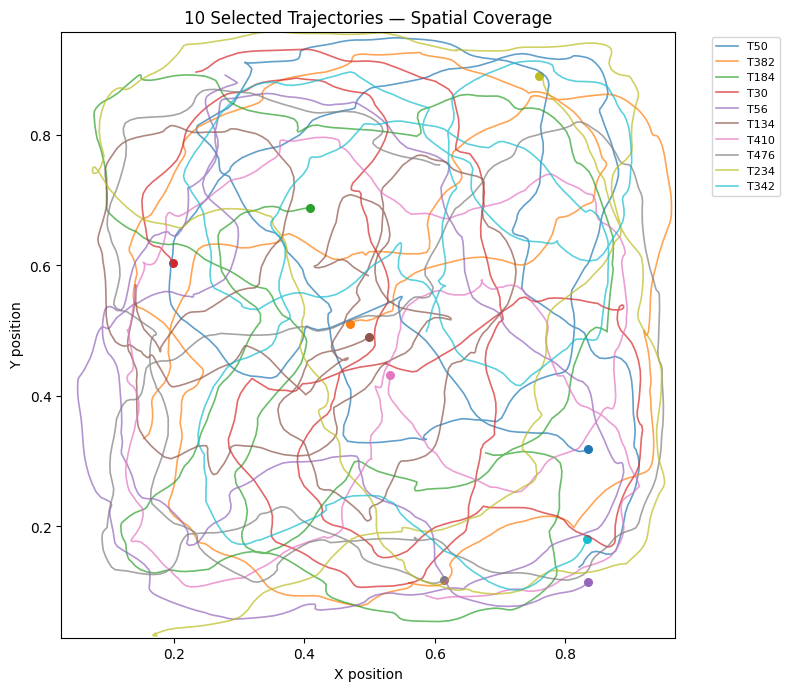

In [32]:
# ============================================================
# VISUALIZE SELECTED TRAJECTORIES
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 8)
)

for i, trajectory in enumerate(
    selected_trajectories,
    start=1
):

    xy = positions[trajectory]

    ax.plot(
        xy[:, 0],
        xy[:, 1],
        linewidth=1.2,
        alpha=0.7,
        label=f"T{trajectory}"
    )

    # Mark starting point
    ax.scatter(
        xy[0, 0],
        xy[0, 1],
        s=30
    )

ax.set_xlim(bounds[0], bounds[1])
ax.set_ylim(bounds[2], bounds[3])

ax.set_aspect("equal")

ax.set_xlabel("X position")
ax.set_ylabel("Y position")

ax.set_title(
    "10 Selected Trajectories — Spatial Coverage"
)

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# CONCATENATE THE 10 SELECTED TRAJECTORIES
# ============================================================
#
# positions:
#     (n_trajectories, time, 2)
#
# activations:
#     (n_trajectories, time, n_neurons)
#
# After concatenation:
#
# positions_concat:
#     (10 * time, 2)
#
# activations_concat:
#     (10 * time, n_neurons)
#
# IMPORTANT:
# We concatenate along the SAMPLE/TIME axis.
# The neuron dimension is preserved.
# ============================================================

print("=" * 70)
print("CONCATENATING SELECTED TRAJECTORIES")
print("=" * 70)

print("Selected trajectories:", selected_trajectories)

# ------------------------------------------------------------
# Extract selected trajectories
# ------------------------------------------------------------

positions_selected = positions[
    selected_trajectories
]

activations_selected = activations[
    selected_trajectories
]

print(
    "\nSelected positions:",
    positions_selected.shape
)

print(
    "Selected activations:",
    activations_selected.shape
)


# ------------------------------------------------------------
# Convert complex activations to magnitude
# ------------------------------------------------------------

activations_selected = np.abs(
    activations_selected
)


# ------------------------------------------------------------
# Concatenate trajectories
# ------------------------------------------------------------

positions_concat = np.concatenate(
    [
        positions_selected[i]
        for i in range(
            len(selected_trajectories)
        )
    ],
    axis=0
)

activations_concat = np.concatenate(
    [
        activations_selected[i]
        for i in range(
            len(selected_trajectories)
        )
    ],
    axis=0
)


# ============================================================
# CHECK SHAPES
# ============================================================

print("\n" + "=" * 70)
print("CONCATENATED DATA")
print("=" * 70)

print(
    "Positions:",
    positions_concat.shape
)

print(
    "Activations:",
    activations_concat.shape
)

print(
    "Number of samples:",
    positions_concat.shape[0]
)

print(
    "Number of neurons:",
    activations_concat.shape[1]
)


# ============================================================
# ASSERTIONS
# ============================================================

assert positions_concat.ndim == 2
assert positions_concat.shape[1] == 2

assert activations_concat.ndim == 2

assert (
    positions_concat.shape[0]
    ==
    activations_concat.shape[0]
)

print("\n✓ Concatenation successful")

CONCATENATING SELECTED TRAJECTORIES
Selected trajectories: [50, 382, 184, 30, 56, 134, 410, 476, 234, 342]

Selected positions: (10, 450, 2)
Selected activations: (10, 450, 100)

CONCATENATED DATA
Positions: (4500, 2)
Activations: (4500, 100)
Number of samples: 4500
Number of neurons: 100

✓ Concatenation successful


CALCULATING CONCATENATED OCCUPANCY MAP

Occupancy shape: (40, 40)
Total samples counted: 4500
Expected samples: 4500
Visited bins: 1230 / 1600
Occupancy probability sum: 1.0
Minimum non-zero occupancy: 1
Maximum occupancy: 17


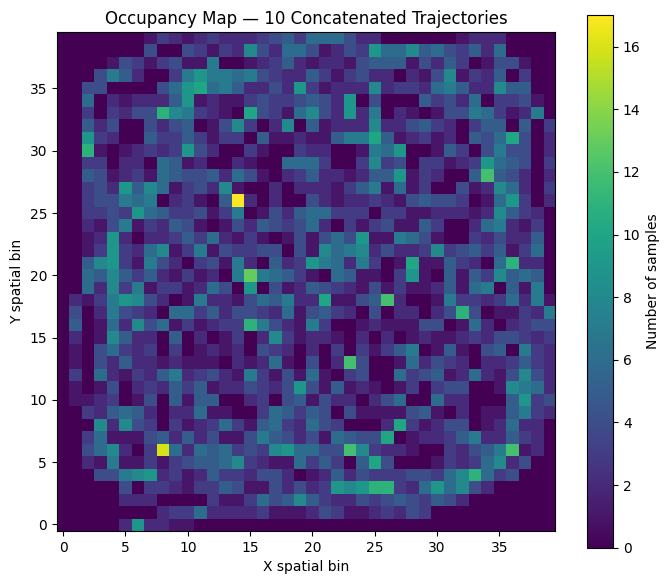

In [36]:
# ============================================================
# OCCUPANCY MAP FOR CONCATENATED TRAJECTORIES
# ============================================================

print("=" * 70)
print("CALCULATING CONCATENATED OCCUPANCY MAP")
print("=" * 70)

# ------------------------------------------------------------
# Bin concatenated positions
# ------------------------------------------------------------

x_bin, y_bin, x_edges, y_edges = bin_positions(
    positions_concat,
    bins=n_bins,
    bounds=bounds,
)

# ------------------------------------------------------------
# Count samples in each spatial bin
# ------------------------------------------------------------

occupancy_counts = np.zeros(
    (n_bins, n_bins),
    dtype=np.int64
)

for xb, yb in zip(x_bin, y_bin):

    if (
        0 <= xb < n_bins
        and
        0 <= yb < n_bins
    ):
        occupancy_counts[xb, yb] += 1


# ------------------------------------------------------------
# Occupancy probability
# ------------------------------------------------------------

total_samples = occupancy_counts.sum()

occupancy_probability = (
    occupancy_counts / total_samples
)


# ============================================================
# REPORT
# ============================================================

print("\nOccupancy shape:", occupancy_counts.shape)

print(
    "Total samples counted:",
    total_samples
)

print(
    "Expected samples:",
    len(positions_concat)
)

print(
    "Visited bins:",
    np.count_nonzero(occupancy_counts),
    "/",
    n_bins * n_bins
)

print(
    "Occupancy probability sum:",
    occupancy_probability.sum()
)

print(
    "Minimum non-zero occupancy:",
    occupancy_counts[
        occupancy_counts > 0
    ].min()
)

print(
    "Maximum occupancy:",
    occupancy_counts.max()
)


# ============================================================
# VISUALIZE OCCUPANCY
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(
    occupancy_counts.T,
    origin="lower",
    aspect="equal",
)

plt.colorbar(
    label="Number of samples"
)

plt.xlabel("X spatial bin")
plt.ylabel("Y spatial bin")

plt.title(
    "Occupancy Map — 10 Concatenated Trajectories"
)

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# FIRING RATE MAPS — 100 NEURONS
# ============================================================

print("=" * 70)
print("CALCULATING FIRING RATE MAPS")
print("=" * 70)

n_neurons = activations_concat.shape[1]

firing_rate_maps = np.zeros(
    (n_neurons, n_bins, n_bins),
    dtype=np.float64
)

# ------------------------------------------------------------
# Accumulate activity in each spatial bin
# ------------------------------------------------------------

for neuron in range(n_neurons):

    activity = activations_concat[:, neuron]

    activity_sum = np.zeros(
        (n_bins, n_bins),
        dtype=np.float64
    )

    for xb, yb, value in zip(
        x_bin,
        y_bin,
        activity
    ):

        if (
            0 <= xb < n_bins
            and
            0 <= yb < n_bins
        ):
            activity_sum[xb, yb] += value

    # --------------------------------------------------------
    # Divide activity by occupancy
    # --------------------------------------------------------

    visited = occupancy_counts > 0

    firing_rate_maps[neuron, visited] = (
        activity_sum[visited]
        /
        occupancy_counts[visited]
    )


# ============================================================
# REPORT
# ============================================================

print(
    "Firing-rate maps shape:",
    firing_rate_maps.shape
)

print(
    "Expected:",
    f"({n_neurons}, {n_bins}, {n_bins})"
)

print(
    "Number of neurons:",
    n_neurons
)

print(
    "Global minimum:",
    firing_rate_maps.min()
)

print(
    "Global maximum:",
    firing_rate_maps.max()
)

print(
    "Mean firing rate:",
    firing_rate_maps[
        firing_rate_maps > 0
    ].mean()
)

print("\n✓ Firing-rate maps calculated")

CALCULATING FIRING RATE MAPS
Firing-rate maps shape: (100, 40, 40)
Expected: (100, 40, 40)
Number of neurons: 100
Global minimum: 0.0
Global maximum: 2.6058329343795776
Mean firing rate: 0.3118969072799886

✓ Firing-rate maps calculated


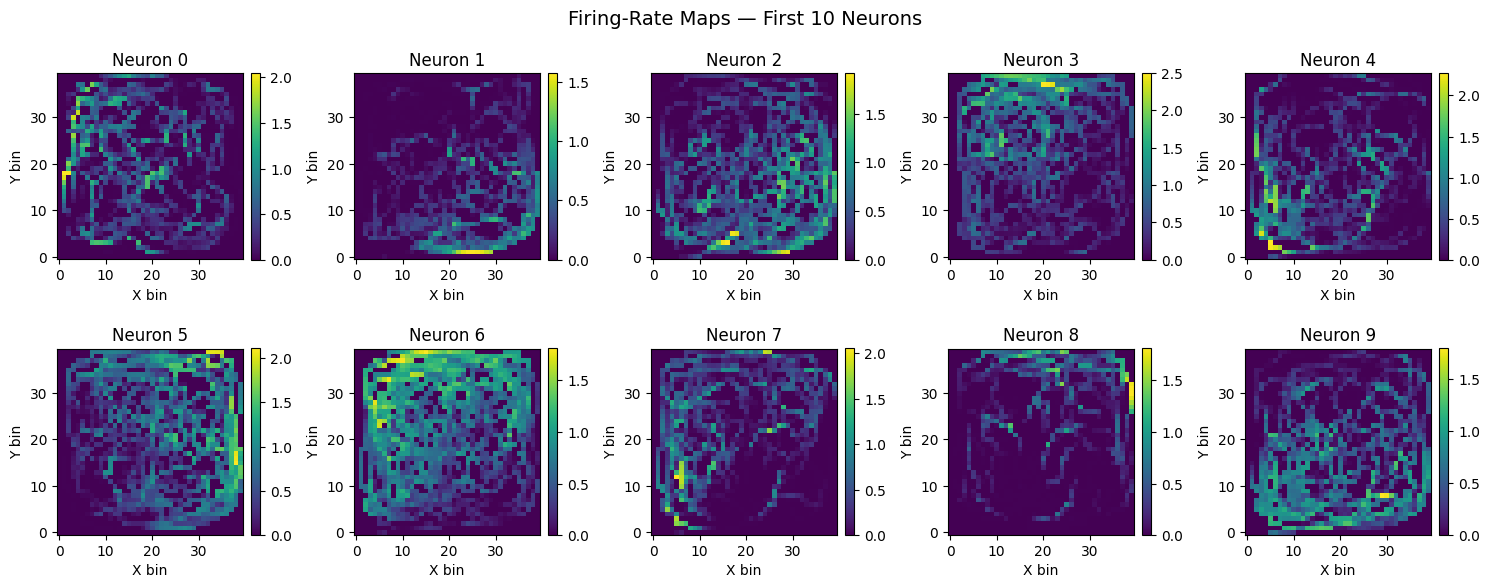

In [38]:
# ============================================================
# VISUALIZE SAMPLE FIRING-RATE MAPS
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

neurons_to_plot = range(10)

for ax, neuron in zip(
    axes.flat,
    neurons_to_plot
):

    im = ax.imshow(
        firing_rate_maps[neuron].T,
        origin="lower",
        aspect="equal"
    )

    ax.set_title(
        f"Neuron {neuron}"
    )

    ax.set_xlabel("X bin")
    ax.set_ylabel("Y bin")

    plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

plt.suptitle(
    "Firing-Rate Maps — First 10 Neurons",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# SMOOTH FIRING-RATE MAPS
# ============================================================

from scipy.ndimage import gaussian_filter

print("=" * 70)
print("SMOOTHING FIRING-RATE MAPS")
print("=" * 70)

print("Input shape:", firing_rate_maps.shape)
print("Gaussian sigma:", SIGMA)

# ------------------------------------------------------------
# Smooth each neuron's firing-rate map
# ------------------------------------------------------------

smoothed_firing_rate_maps = np.zeros_like(
    firing_rate_maps
)

for neuron in range(n_neurons):

    # Smooth the firing-rate map
    smoothed_map = gaussian_filter(
        firing_rate_maps[neuron],
        sigma=SIGMA
    )

    # Keep unvisited bins as zero
    smoothed_map[
        occupancy_counts == 0
    ] = 0

    smoothed_firing_rate_maps[
        neuron
    ] = smoothed_map


# ============================================================
# CHECK
# ============================================================

print(
    "Output shape:",
    smoothed_firing_rate_maps.shape
)

print(
    "Minimum:",
    smoothed_firing_rate_maps.min()
)

print(
    "Maximum:",
    smoothed_firing_rate_maps.max()
)

print(
    "Mean:",
    smoothed_firing_rate_maps[
        smoothed_firing_rate_maps > 0
    ].mean()
)

print("\n✓ Smoothing complete")

SMOOTHING FIRING-RATE MAPS
Input shape: (100, 40, 40)
Gaussian sigma: 1.0
Output shape: (100, 40, 40)
Minimum: 0.0
Maximum: 1.8930207381371977
Mean: 0.2706001634856097

✓ Smoothing complete


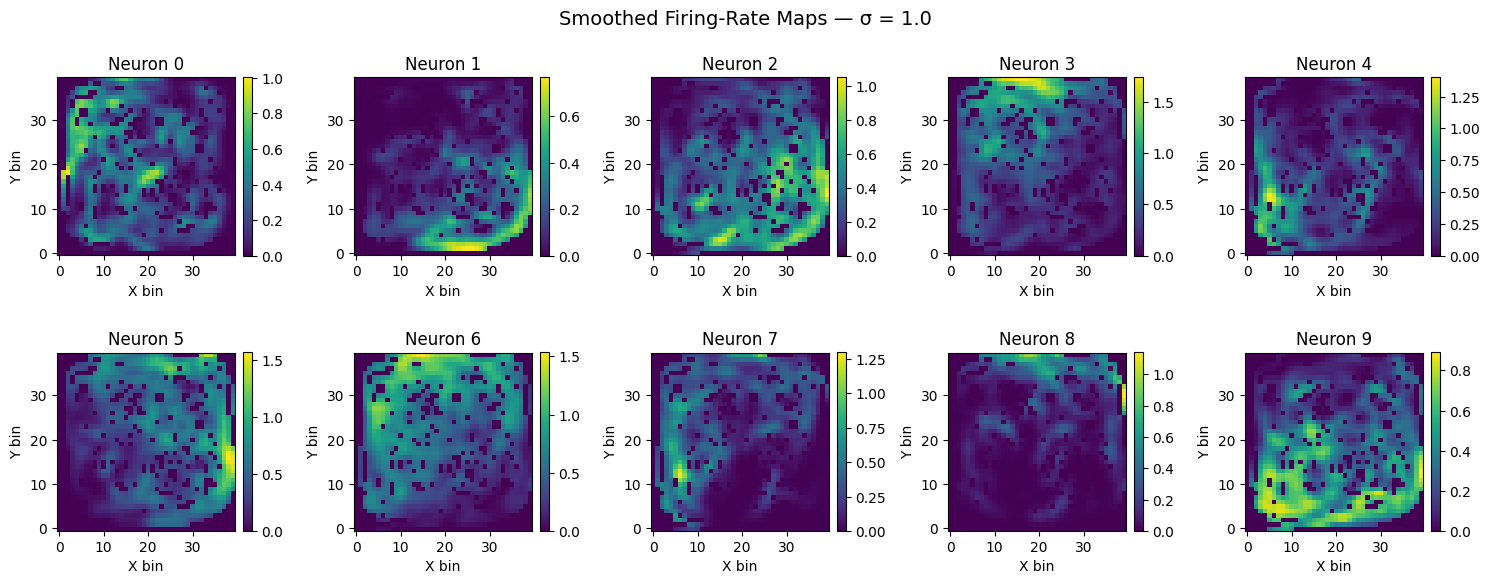

In [40]:
# ============================================================
# VISUALIZE SMOOTHED FIRING-RATE MAPS
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

neurons_to_plot = range(10)

for ax, neuron in zip(
    axes.flat,
    neurons_to_plot
):

    im = ax.imshow(
        smoothed_firing_rate_maps[neuron].T,
        origin="lower",
        aspect="equal"
    )

    ax.set_title(
        f"Neuron {neuron}"
    )

    ax.set_xlabel("X bin")
    ax.set_ylabel("Y bin")

    plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

plt.suptitle(
    f"Smoothed Firing-Rate Maps — σ = {SIGMA}",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# SPATIAL AUTOCORRELATION — ALL 100 NEURONS
# ============================================================

print("=" * 70)
print("CALCULATING SPATIAL AUTOCORRELATION MAPS")
print("=" * 70)

autocorr_maps = np.full(
    (
        n_neurons,
        2 * n_bins - 1,
        2 * n_bins - 1
    ),
    np.nan,
    dtype=np.float32
)

for neuron in range(n_neurons):

    autocorr_maps[neuron] = (
        spatial_autocorrelation(
            smoothed_firing_rate_maps[neuron]
        )
    )

print(
    "Autocorrelation maps shape:",
    autocorr_maps.shape
)

print(
    "Expected:",
    f"({n_neurons}, {2*n_bins-1}, {2*n_bins-1})"
)

print(
    "Autocorrelation map size:",
    2 * n_bins - 1,
    "x",
    2 * n_bins - 1
)

print("\n✓ Autocorrelation calculation complete")

CALCULATING SPATIAL AUTOCORRELATION MAPS
Autocorrelation maps shape: (100, 79, 79)
Expected: (100, 79, 79)
Autocorrelation map size: 79 x 79

✓ Autocorrelation calculation complete


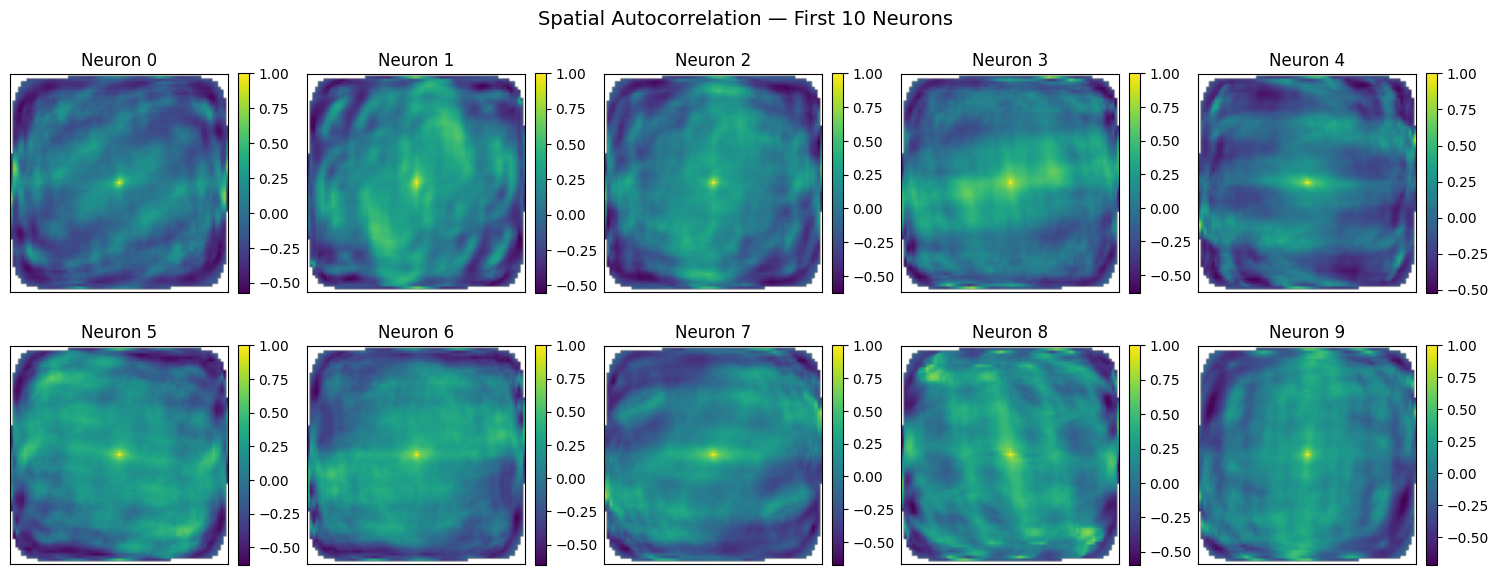

In [42]:
# ============================================================
# VISUALIZE AUTOCORRELATION MAPS
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

for ax, neuron in zip(
    axes.flat,
    range(10)
):

    im = ax.imshow(
        autocorr_maps[neuron],
        origin="lower",
        aspect="equal"
    )

    ax.set_title(
        f"Neuron {neuron}"
    )

    ax.set_xticks([])
    ax.set_yticks([])

    plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

plt.suptitle(
    "Spatial Autocorrelation — First 10 Neurons",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [44]:
 # ============================================================
# GRID SCORE — ALL 100 NEURONS
# ============================================================

print("=" * 70)
print("CALCULATING GRID SCORES")
print("=" * 70)

grid_scores = np.full(
    n_neurons,
    np.nan,
    dtype=float
)

grid_correlations = {}

grid_radii = {}

grid_peaks = {}

grid_centres = {}


# ============================================================
# CALCULATE GRID SCORE FOR EACH NEURON
# ============================================================

for neuron in range(n_neurons):

    autocorr = autocorr_maps[neuron]

    # --------------------------------------------------------
    # Detect autocorrelation peaks
    # --------------------------------------------------------

    peaks = detect_autocorr_peaks(
        autocorr
    )

    peaks = merge_close_peaks(
        peaks,
        min_distance=6,
    )

    if len(peaks) == 0:
        continue

    # --------------------------------------------------------
    # Find centre peak
    # --------------------------------------------------------

    centre = centre_peak(
        peaks,
        autocorr.shape,
    )

    # --------------------------------------------------------
    # Find first ring radius
    # --------------------------------------------------------

    radius = first_ring_radius(
        peaks,
        centre,
    )

    if radius is None:
        continue

    # --------------------------------------------------------
    # Calculate grid score
    # --------------------------------------------------------

    score, correlations = compute_grid_score(
        autocorr,
        inner_radius=0.5 * radius,
        outer_radius=1.5 * radius,
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    grid_scores[neuron] = score

    grid_correlations[neuron] = correlations

    grid_radii[neuron] = radius

    grid_peaks[neuron] = peaks

    grid_centres[neuron] = centre

    if (neuron + 1) % 10 == 0:
        print(
            f"Completed {neuron + 1}/{n_neurons}"
        )


# ============================================================
# RESULTS TABLE
# ============================================================

grid_results = pd.DataFrame({
    "Neuron": np.arange(n_neurons),
    "Grid Score": grid_scores,
})


grid_results = grid_results.sort_values(
    "Grid Score",
    ascending=False
).reset_index(drop=True)


# ============================================================
# TOP 20
# ============================================================

print("\n" + "=" * 70)
print("TOP 20 NEURONS BY GRID SCORE")
print("=" * 70)

display(
    grid_results
    .head(20)
    .round(4)
)


# ============================================================
# SUMMARY
# ============================================================

valid_scores = grid_scores[
    np.isfinite(grid_scores)
]

print("\n" + "=" * 70)
print("GRID SCORE SUMMARY")
print("=" * 70)

print(
    "Valid neurons:",
    len(valid_scores),
    "/",
    n_neurons
)

if len(valid_scores) > 0:

    print(
        "Maximum:",
        np.max(valid_scores)
    )

    print(
        "Minimum:",
        np.min(valid_scores)
    )

    print(
        "Mean:",
        np.mean(valid_scores)
    )

    print(
        "Median:",
        np.median(valid_scores)
    )

CALCULATING GRID SCORES
Completed 10/100
Completed 20/100
Completed 30/100
Completed 40/100
Completed 50/100
Completed 60/100
Completed 70/100
Completed 80/100
Completed 90/100
Completed 100/100

TOP 20 NEURONS BY GRID SCORE


,Neuron,Grid Score
0,56,0.5376
1,94,0.3066
2,80,0.2557
3,55,0.2238
4,14,0.2204
5,4,0.1771
6,53,0.1609
7,7,0.1421
8,65,0.1127
9,33,0.0974



GRID SCORE SUMMARY
Valid neurons: 100 / 100
Maximum: 0.5375622260608846
Minimum: -0.454220279334012
Mean: -0.12823491507848078
Median: -0.17539591886632105


In [45]:
# ============================================================
# TOP GRID-SCORE CANDIDATES
# ============================================================

print("=" * 70)
print("TOP 20 GRID-SCORE CANDIDATES")
print("=" * 70)

top_candidates = grid_results.head(20).copy()

print(
    top_candidates.to_string(
        index=False
    )
)

print("\nCandidate neurons:")
print(
    top_candidates["Neuron"].tolist()
)

TOP 20 GRID-SCORE CANDIDATES
 Neuron  Grid Score
     56    0.537562
     94    0.306645
     80    0.255663
     55    0.223842
     14    0.220373
      4    0.177118
     53    0.160926
      7    0.142126
     65    0.112721
     33    0.097350
     38    0.096065
     78    0.095195
     23    0.094637
     10    0.091275
     62    0.091049
     20    0.085842
     59    0.073605
     81    0.065677
     91    0.064842
     13    0.059136

Candidate neurons:
[56, 94, 80, 55, 14, 4, 53, 7, 65, 33, 38, 78, 23, 10, 62, 20, 59, 81, 91, 13]


In [46]:
# ============================================================
# PREPARE GRID-CELL SHUFFLE TEST
# ============================================================

n_shuffles = 250

candidate_neurons = (
    grid_results
    .head(20)["Neuron"]
    .astype(int)
    .tolist()
)

print("=" * 70)
print("GRID-CELL SHUFFLE TEST")
print("=" * 70)

print(
    "Number of candidates:",
    len(candidate_neurons)
)

print(
    "Number of shuffles per candidate:",
    n_shuffles
)

print("\nCandidates:")
print(candidate_neurons)


# ============================================================
# CHECK FIXED RADII
# ============================================================

shuffle_radii = {}

for neuron in candidate_neurons:

    if neuron not in grid_radii:
        print(
            f"WARNING: No radius found for neuron {neuron}"
        )
        continue

    shuffle_radii[neuron] = grid_radii[neuron]


print("\n" + "=" * 70)
print("FIXED RADII")
print("=" * 70)

for neuron in candidate_neurons:

    if neuron in shuffle_radii:

        print(
            f"Neuron {neuron:3d} | "
            f"Grid score = {grid_scores[neuron]: .4f} | "
            f"Radius = {shuffle_radii[neuron]: .2f}"
        )

GRID-CELL SHUFFLE TEST
Number of candidates: 20
Number of shuffles per candidate: 250

Candidates:
[56, 94, 80, 55, 14, 4, 53, 7, 65, 33, 38, 78, 23, 10, 62, 20, 59, 81, 91, 13]

FIXED RADII
Neuron  56 | Grid score =  0.5376 | Radius =  17.49
Neuron  94 | Grid score =  0.3066 | Radius =  15.66
Neuron  80 | Grid score =  0.2557 | Radius =  15.65
Neuron  55 | Grid score =  0.2238 | Radius =  11.66
Neuron  14 | Grid score =  0.2204 | Radius =  17.03
Neuron   4 | Grid score =  0.1771 | Radius =  23.75
Neuron  53 | Grid score =  0.1609 | Radius =  20.22
Neuron   7 | Grid score =  0.1421 | Radius =  21.21
Neuron  65 | Grid score =  0.1127 | Radius =  14.76
Neuron  33 | Grid score =  0.0974 | Radius =  11.20
Neuron  38 | Grid score =  0.0961 | Radius =  14.32
Neuron  78 | Grid score =  0.0952 | Radius =  11.88
Neuron  23 | Grid score =  0.0946 | Radius =  17.92
Neuron  10 | Grid score =  0.0913 | Radius =  15.03
Neuron  62 | Grid score =  0.0910 | Radius =  16.76
Neuron  20 | Grid score =  0.

In [47]:
# ============================================================
# CIRCULAR SHUFFLE TEST — 20 CANDIDATES
# ============================================================

import time
from scipy.ndimage import gaussian_filter

print("=" * 70)
print("STARTING CIRCULAR SHUFFLE TEST")
print("=" * 70)

n_shuffles = 250

shuffle_scores = {
    neuron: []
    for neuron in candidate_neurons
}

rng = np.random.default_rng(42)

start_time = time.time()


# ============================================================
# SHUFFLE EACH CANDIDATE
# ============================================================

for candidate_index, neuron in enumerate(candidate_neurons):

    print(
        f"\n[{candidate_index + 1}/{len(candidate_neurons)}] "
        f"Neuron {neuron}"
    )

    activity_original = (
        activations_concat[:, neuron]
    )

    fixed_radius = shuffle_radii[neuron]

    candidate_shuffle_scores = []

    for shuffle in range(n_shuffles):

        # ----------------------------------------------------
        # Circularly shift activity
        # ----------------------------------------------------

        shift = rng.integers(
            1,
            len(activity_original)
        )

        shuffled_activity = np.roll(
            activity_original,
            shift
        )


        # ----------------------------------------------------
        # Accumulate shuffled activity into spatial bins
        # ----------------------------------------------------

        activity_sum = np.zeros(
            (n_bins, n_bins),
            dtype=np.float64
        )

        for xb, yb, value in zip(
            x_bin,
            y_bin,
            shuffled_activity
        ):

            if (
                0 <= xb < n_bins
                and
                0 <= yb < n_bins
            ):
                activity_sum[xb, yb] += value


        # ----------------------------------------------------
        # Calculate shuffled firing-rate map
        # ----------------------------------------------------

        shuffled_rate_map = np.zeros(
            (n_bins, n_bins),
            dtype=np.float64
        )

        visited = occupancy_counts > 0

        shuffled_rate_map[visited] = (
            activity_sum[visited]
            /
            occupancy_counts[visited]
        )


        # ----------------------------------------------------
        # Smooth
        # ----------------------------------------------------

        shuffled_rate_map = gaussian_filter(
            shuffled_rate_map,
            sigma=SIGMA
        )

        shuffled_rate_map[
            occupancy_counts == 0
        ] = 0


        # ----------------------------------------------------
        # Spatial autocorrelation
        # ----------------------------------------------------

        shuffled_autocorr = (
            spatial_autocorrelation(
                shuffled_rate_map
            )
        )


        # ----------------------------------------------------
        # Calculate grid score using FIXED radius
        # ----------------------------------------------------

        score, _ = compute_grid_score(
            shuffled_autocorr,
            inner_radius=0.5 * fixed_radius,
            outer_radius=1.5 * fixed_radius,
        )

        candidate_shuffle_scores.append(
            score
        )


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (shuffle + 1) % 50 == 0:

            print(
                f"    {shuffle + 1}/{n_shuffles}"
            )


    shuffle_scores[neuron] = np.array(
        candidate_shuffle_scores
    )

    elapsed = time.time() - start_time

    print(
        f"    Real score: {grid_scores[neuron]:.4f}"
    )

    print(
        f"    Shuffle mean: "
        f"{np.mean(shuffle_scores[neuron]):.4f}"
    )

    print(
        f"    Elapsed: {elapsed / 60:.2f} min"
    )


# ============================================================
# COMPLETION
# ============================================================

total_time = time.time() - start_time

print("\n" + "=" * 70)
print("SHUFFLE TEST COMPLETE")
print("=" * 70)

print(
    f"Total time: {total_time / 60:.2f} minutes"
)

print(
    f"Candidates tested: {len(candidate_neurons)}"
)

print(
    f"Shuffles per candidate: {n_shuffles}"
)

print("\n✓ All shuffle distributions calculated")

STARTING CIRCULAR SHUFFLE TEST

[1/20] Neuron 56
    50/250
    100/250
    150/250
    200/250
    250/250
    Real score: 0.5376
    Shuffle mean: -0.0710
    Elapsed: 3.20 min

[2/20] Neuron 94
    50/250
    100/250
    150/250
    200/250
    250/250
    Real score: 0.3066
    Shuffle mean: -0.0741
    Elapsed: 5.07 min

[3/20] Neuron 80
    50/250
    100/250
    150/250
    200/250
    250/250
    Real score: 0.2557
    Shuffle mean: -0.0482
    Elapsed: 6.33 min

[4/20] Neuron 55
    50/250
    100/250
    150/250
    200/250
    250/250
    Real score: 0.2238
    Shuffle mean: -0.1409
    Elapsed: 7.60 min

[5/20] Neuron 14
    50/250
    100/250
    150/250
    200/250
    250/250
    Real score: 0.2204
    Shuffle mean: -0.1075
    Elapsed: 8.88 min

[6/20] Neuron 4
    50/250
    100/250
    150/250
    200/250
    250/250
    Real score: 0.1771
    Shuffle mean: 0.0349
    Elapsed: 10.17 min

[7/20] Neuron 53
    50/250
    100/250
    150/250
    200/250
    250/250
    R

In [49]:
# ============================================================
# GRID-CELL SIGNIFICANCE FROM SHUFFLES
# ============================================================

print("=" * 70)
print("GRID-CELL SIGNIFICANCE ANALYSIS")
print("=" * 70)

alpha = 0.05
n_tests = len(candidate_neurons)

# Bonferroni correction for the 20 candidate neurons
bonferroni_alpha = alpha / n_tests

significance_results = []


# ============================================================
# ANALYZE EACH CANDIDATE
# ============================================================

for neuron in candidate_neurons:

    real_score = grid_scores[neuron]

    shuffled = np.asarray(
        shuffle_scores[neuron]
    )

    shuffle_mean = np.mean(shuffled)
    shuffle_std = np.std(shuffled, ddof=1)

    # --------------------------------------------------------
    # 95th percentile of null distribution
    # --------------------------------------------------------

    percentile_95 = np.percentile(
        shuffled,
        95
    )

    percentile_99 = np.percentile(
        shuffled,
        99
    )

    # --------------------------------------------------------
    # Empirical one-sided p-value
    #
    # +1 correction prevents p = 0
    # --------------------------------------------------------

    n_greater_or_equal = np.sum(
        shuffled >= real_score
    )

    empirical_p = (
        n_greater_or_equal + 1
    ) / (
        len(shuffled) + 1
    )

    # --------------------------------------------------------
    # Significance criteria
    # --------------------------------------------------------

    above_95 = (
        real_score > percentile_95
    )

    significant_p05 = (
        empirical_p < alpha
    )

    significant_bonferroni = (
        empirical_p < bonferroni_alpha
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    significance_results.append({

        "Neuron": neuron,

        "Real Score": real_score,

        "Shuffle Mean": shuffle_mean,

        "Shuffle SD": shuffle_std,

        "95th Percentile": percentile_95,

        "99th Percentile": percentile_99,

        "Empirical p": empirical_p,

        "Above 95%": above_95,

        "p < 0.05": significant_p05,

        "Bonferroni p < 0.0025":
            significant_bonferroni,
    })


# ============================================================
# RESULTS TABLE
# ============================================================

significance_results = pd.DataFrame(
    significance_results
)

significance_results = (
    significance_results
    .sort_values(
        "Real Score",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# DISPLAY
# ============================================================

pd.set_option(
    "display.max_columns",
    None
)

display(
    significance_results.round(4)
)


# ============================================================
# FINAL COUNTS
# ============================================================

print("\n" + "=" * 70)
print("SIGNIFICANCE SUMMARY")
print("=" * 70)

print(
    "Above 95th percentile:",
    significance_results[
        "Above 95%"
    ].sum()
)

print(
    "Empirical p < 0.05:",
    significance_results[
        "p < 0.05"
    ].sum()
)

print(
    "Bonferroni significant:",
    significance_results[
        "Bonferroni p < 0.0025"
    ].sum()
)

print(
    "\nBonferroni alpha:",
    bonferroni_alpha
)

GRID-CELL SIGNIFICANCE ANALYSIS


,Neuron,Real Score,Shuffle Mean,Shuffle SD,95th Percentile,99th Percentile,Empirical p,Above 95%,p < 0.05,Bonferroni p < 0.0025
0,56,0.5376,-0.0710,0.1964,0.3310,0.4925,0.0080,True,True,False
1,94,0.3066,-0.0741,0.2360,0.3241,0.6832,0.0637,False,False,False
2,80,0.2557,-0.0482,0.1880,0.2560,0.4874,0.0558,False,False,False
3,55,0.2238,-0.1409,0.1613,0.1939,0.2624,0.0319,True,True,False
4,14,0.2204,-0.1075,0.1835,0.2959,0.4472,0.0876,False,False,False
5,4,0.1771,0.0349,0.1942,0.3838,0.5373,0.2430,False,False,False
6,53,0.1609,0.0037,0.1916,0.3363,0.5923,0.1793,False,False,False
7,7,0.1421,0.0409,0.2329,0.4876,0.7440,0.2829,False,False,False
8,65,0.1127,-0.1052,0.1989,0.3152,0.4273,0.1434,False,False,False
9,33,0.0974,-0.1543,0.1736,0.1558,0.4487,0.1036,False,False,False



SIGNIFICANCE SUMMARY
Above 95th percentile: 2
Empirical p < 0.05: 2
Bonferroni significant: 0

Bonferroni alpha: 0.0025


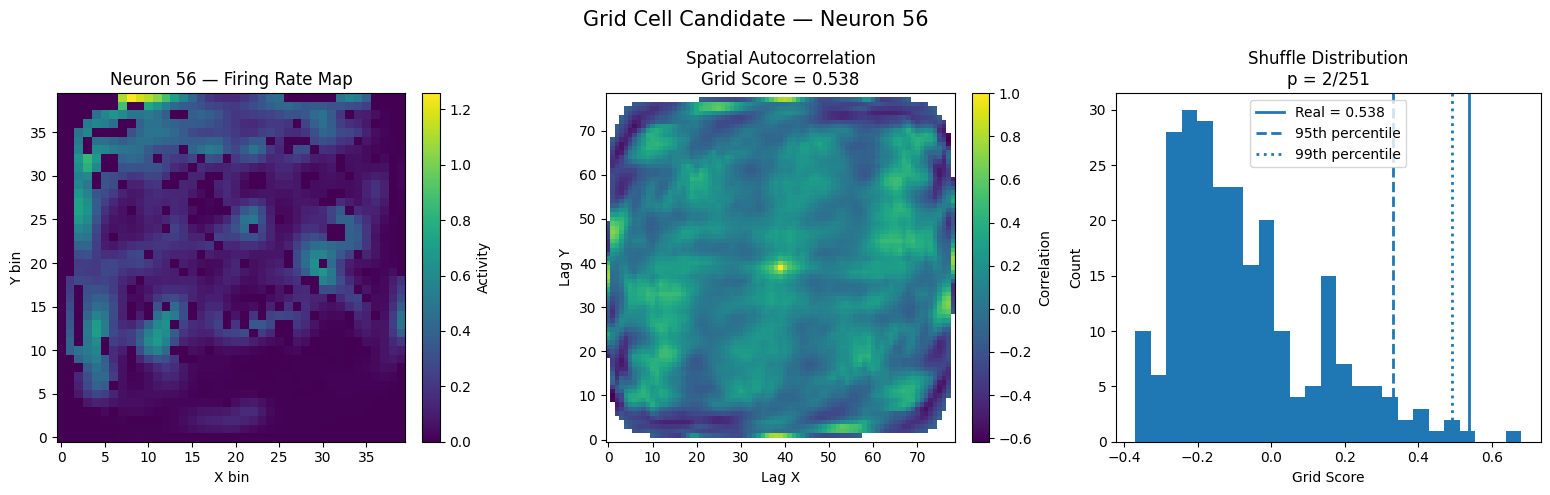

In [50]:
# ============================================================
# NEURON 56 — GRID-CELL VISUALIZATION
# ============================================================

neuron = 56

real_score = grid_scores[neuron]
shuffled = shuffle_scores[neuron]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)


# ============================================================
# 1. FIRING RATE MAP
# ============================================================

im1 = axes[0].imshow(
    smoothed_firing_rate_maps[neuron].T,
    origin="lower",
    aspect="equal"
)

axes[0].set_title(
    f"Neuron {neuron} — Firing Rate Map"
)

axes[0].set_xlabel("X bin")
axes[0].set_ylabel("Y bin")

plt.colorbar(
    im1,
    ax=axes[0],
    fraction=0.046,
    pad=0.04,
    label="Activity"
)


# ============================================================
# 2. AUTOCORRELATION
# ============================================================

im2 = axes[1].imshow(
    autocorr_maps[neuron],
    origin="lower",
    aspect="equal"
)

axes[1].set_title(
    f"Spatial Autocorrelation\n"
    f"Grid Score = {real_score:.3f}"
)

axes[1].set_xlabel("Lag X")
axes[1].set_ylabel("Lag Y")

plt.colorbar(
    im2,
    ax=axes[1],
    fraction=0.046,
    pad=0.04,
    label="Correlation"
)


# ============================================================
# 3. SHUFFLE DISTRIBUTION
# ============================================================

axes[2].hist(
    shuffled,
    bins=25
)

axes[2].axvline(
    real_score,
    linewidth=2,
    label=f"Real = {real_score:.3f}"
)

axes[2].axvline(
    np.percentile(shuffled, 95),
    linestyle="--",
    linewidth=2,
    label="95th percentile"
)

axes[2].axvline(
    np.percentile(shuffled, 99),
    linestyle=":",
    linewidth=2,
    label="99th percentile"
)

axes[2].set_title(
    f"Shuffle Distribution\n"
    f"p = {np.sum(shuffled >= real_score)+1}/"
    f"{len(shuffled)+1}"
)

axes[2].set_xlabel("Grid Score")
axes[2].set_ylabel("Count")

axes[2].legend()


plt.suptitle(
    "Grid Cell Candidate — Neuron 56",
    fontsize=15
)

plt.tight_layout()
plt.show()

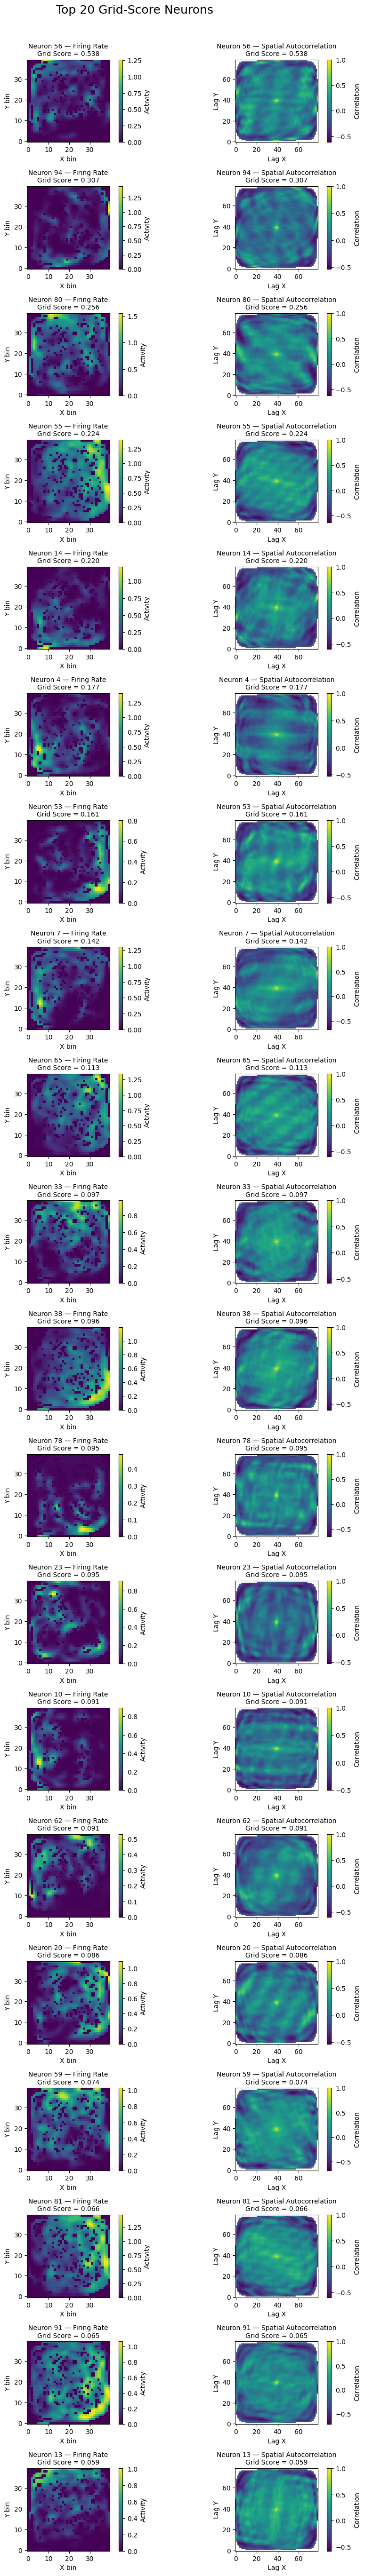

In [52]:
# ============================================================
# TOP 20 — FIRING RATE + AUTOCORRELATION SIDE BY SIDE
# ============================================================

top_20_neurons = (
    grid_results
    .head(20)["Neuron"]
    .astype(int)
    .tolist()
)

fig, axes = plt.subplots(
    20,
    2,
    figsize=(10, 55)
)

for row, neuron in enumerate(top_20_neurons):

    score = grid_scores[neuron]

    # ========================================================
    # FIRING RATE MAP
    # ========================================================

    ax_fr = axes[row, 0]

    im1 = ax_fr.imshow(
        smoothed_firing_rate_maps[neuron].T,
        origin="lower",
        aspect="equal"
    )

    ax_fr.set_title(
        f"Neuron {neuron} — Firing Rate\n"
        f"Grid Score = {score:.3f}",
        fontsize=10
    )

    ax_fr.set_xlabel("X bin")
    ax_fr.set_ylabel("Y bin")

    plt.colorbar(
        im1,
        ax=ax_fr,
        fraction=0.046,
        pad=0.04,
        label="Activity"
    )


    # ========================================================
    # AUTOCORRELATION
    # ========================================================

    ax_ac = axes[row, 1]

    im2 = ax_ac.imshow(
        autocorr_maps[neuron],
        origin="lower",
        aspect="equal"
    )

    ax_ac.set_title(
        f"Neuron {neuron} — Spatial Autocorrelation\n"
        f"Grid Score = {score:.3f}",
        fontsize=10
    )

    ax_ac.set_xlabel("Lag X")
    ax_ac.set_ylabel("Lag Y")

    plt.colorbar(
        im2,
        ax=ax_ac,
        fraction=0.046,
        pad=0.04,
        label="Correlation"
    )


# ============================================================
# OVERALL TITLE
# ============================================================

fig.suptitle(
    "Top 20 Grid-Score Neurons",
    fontsize=18,
    y=0.995
)

plt.tight_layout(
    rect=[0, 0, 1, 0.99]
)

plt.show()

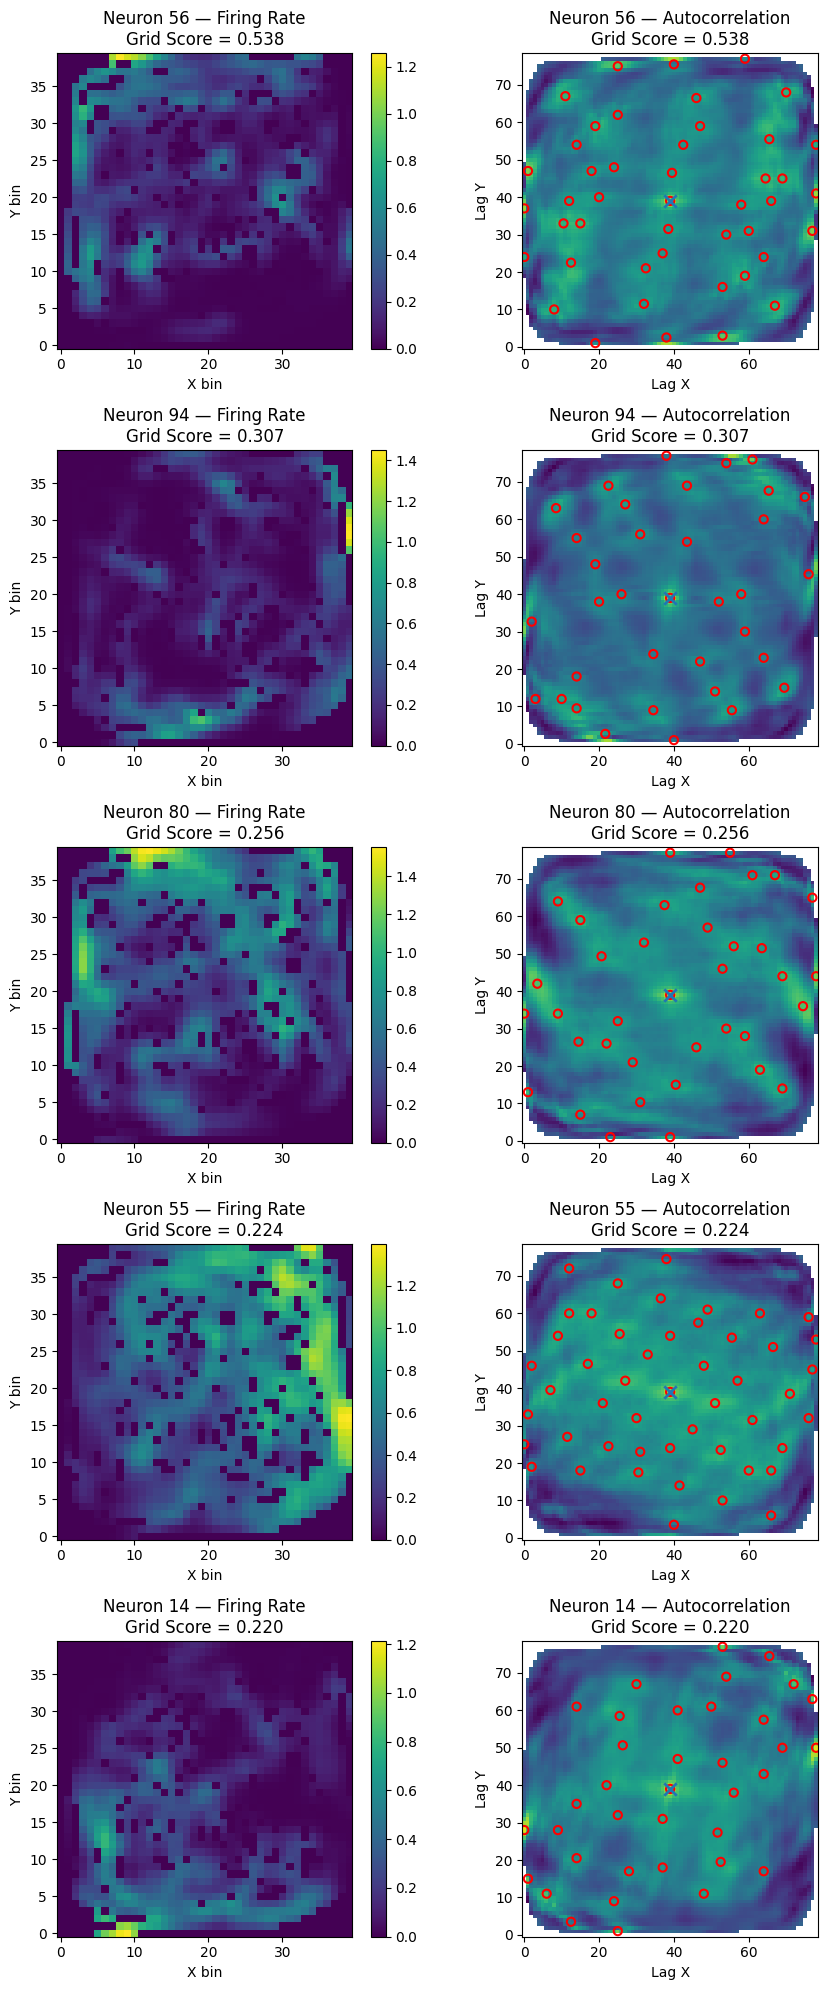

In [53]:
# ============================================================
# INSPECT GRID-SCORE GEOMETRY FOR TOP 5
# ============================================================

top_5 = [56, 94, 80, 55, 14]

fig, axes = plt.subplots(
    len(top_5),
    2,
    figsize=(10, 4 * len(top_5))
)

for row, neuron in enumerate(top_5):

    score = grid_scores[neuron]

    # --------------------------------------------------------
    # Firing-rate map
    # --------------------------------------------------------

    ax = axes[row, 0]

    im = ax.imshow(
        smoothed_firing_rate_maps[neuron].T,
        origin="lower",
        aspect="equal"
    )

    ax.set_title(
        f"Neuron {neuron} — Firing Rate\n"
        f"Grid Score = {score:.3f}"
    )

    ax.set_xlabel("X bin")
    ax.set_ylabel("Y bin")

    plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )


    # --------------------------------------------------------
    # Autocorrelation
    # --------------------------------------------------------

    ax = axes[row, 1]

    autocorr = autocorr_maps[neuron]

    ax.imshow(
        autocorr,
        origin="lower",
        aspect="equal"
    )

    # --------------------------------------------------------
    # Plot detected peaks
    # --------------------------------------------------------

    peaks = grid_peaks[neuron]

    if len(peaks) > 0:

        peaks_array = np.asarray(peaks)

        ax.scatter(
            peaks_array[:, 1],
            peaks_array[:, 0],
            s=35,
            facecolors="none",
            edgecolors="red",
            linewidths=1.5,
        )


    # --------------------------------------------------------
    # Centre
    # --------------------------------------------------------

    centre = grid_centres[neuron]

    if centre is not None:

        ax.scatter(
            centre[1],
            centre[0],
            s=80,
            marker="x",
            linewidths=2
        )


    ax.set_title(
        f"Neuron {neuron} — Autocorrelation\n"
        f"Grid Score = {score:.3f}"
    )

    ax.set_xlabel("Lag X")
    ax.set_ylabel("Lag Y")


plt.tight_layout()
plt.show()

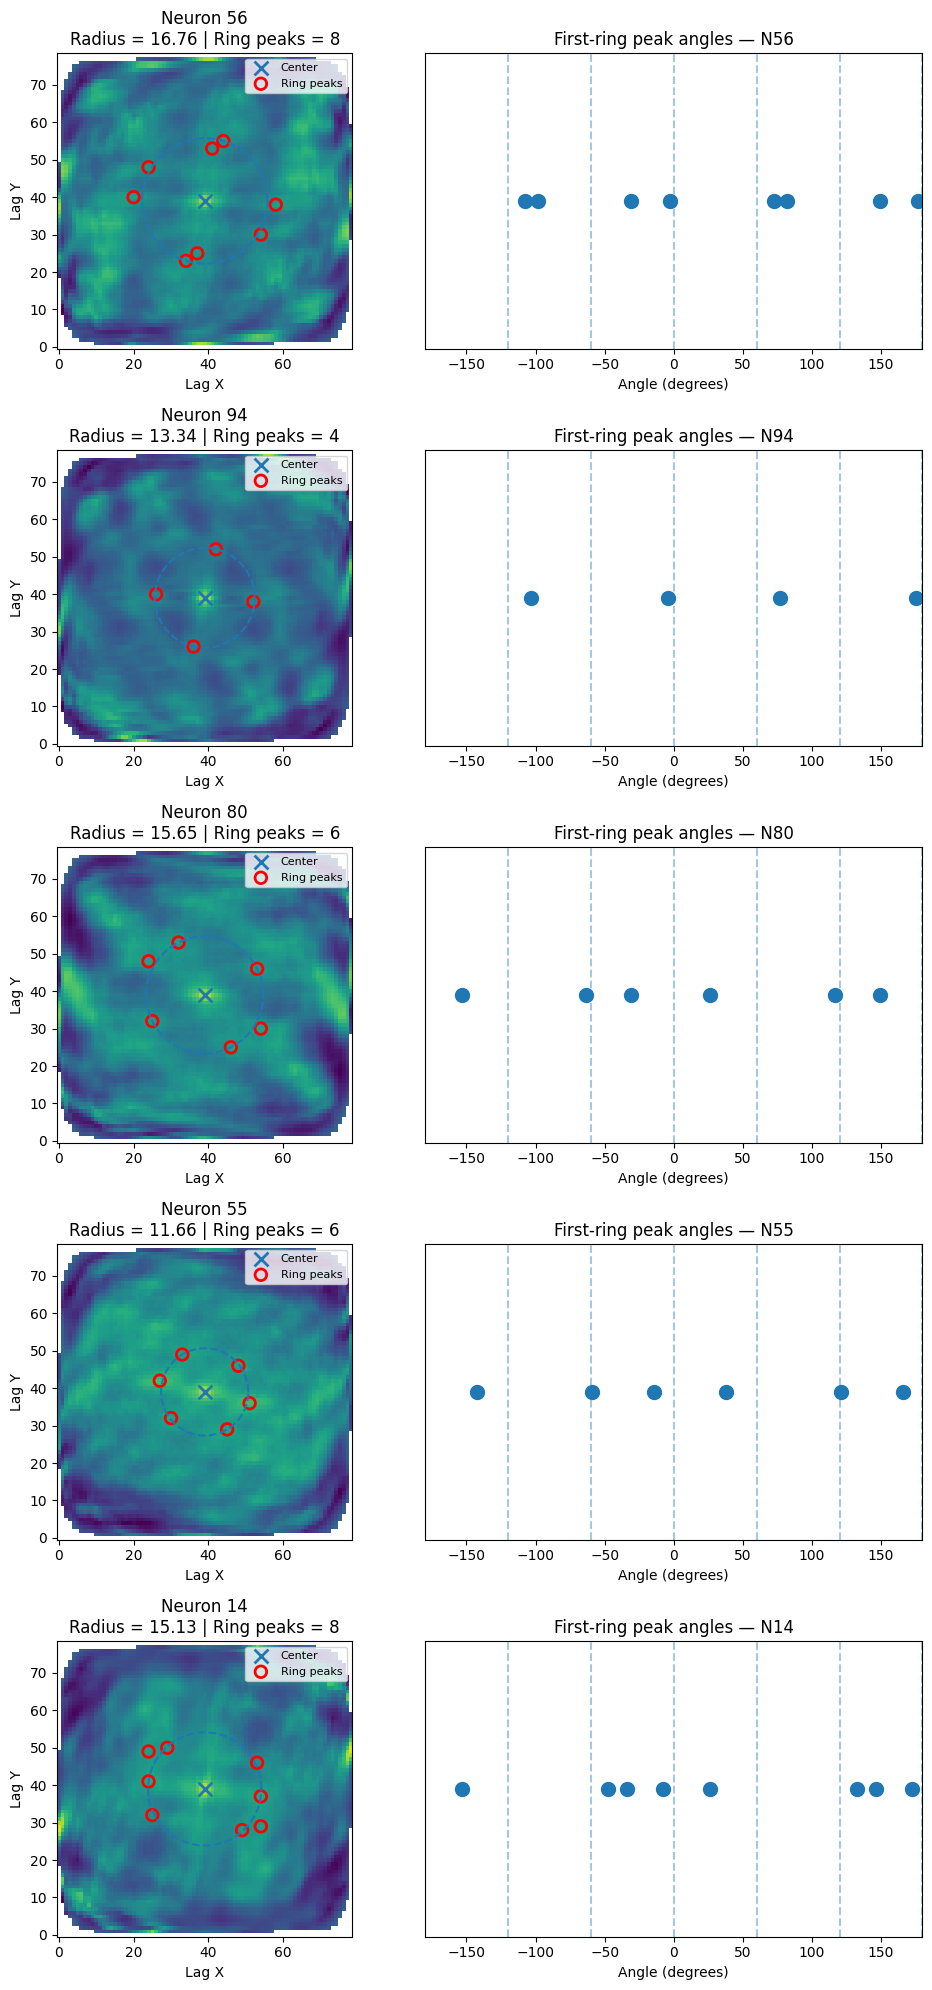

In [60]:
# ============================================================
# FIRST-RING PEAK ANALYSIS
# ============================================================

top_5 = [56, 94, 80, 55, 14]

fig, axes = plt.subplots(
    len(top_5),
    2,
    figsize=(10, 4 * len(top_5))
)

for row, neuron in enumerate(top_5):

    autocorr = autocorr_maps[neuron]

    # ========================================================
    # 1. DETECT PEAKS
    # ========================================================

    peaks = detect_autocorr_peaks(
        autocorr
    )

    peaks = np.asarray(peaks)

    if peaks.ndim == 1:
        peaks = peaks.reshape(-1, 2)

    # ========================================================
    # 2. FIND CENTRAL PEAK
    # ========================================================

    center = centre_peak(
        peaks,
        autocorr.shape
    )

    # ========================================================
    # 3. FIND FIRST-RING RADIUS
    # ========================================================

    radius = first_ring_radius(
        peaks,
        center
    )

    # ========================================================
    # 4. CREATE ANNULUS DIRECTLY
    # ========================================================

    yy, xx = np.indices(
        autocorr.shape
    )

    distances = np.sqrt(
        (xx - center[1]) ** 2
        +
        (yy - center[0]) ** 2
    )

    # Use a tolerance around the first-ring radius
    ring_tolerance = max(
        2.0,
        radius * 0.20
    )

    annulus = (
        distances >= radius - ring_tolerance
    ) & (
        distances <= radius + ring_tolerance
    )

    # ========================================================
    # 5. KEEP DETECTED PEAKS IN FIRST RING
    # ========================================================

    ring_peaks = []

    for peak in peaks:

        y = int(peak[0])
        x = int(peak[1])

        if (
            0 <= y < autocorr.shape[0]
            and
            0 <= x < autocorr.shape[1]
            and
            annulus[y, x]
        ):

            ring_peaks.append(
                peak
            )

    ring_peaks = np.asarray(
        ring_peaks
    )

    # ========================================================
    # 6. AUTOCORRELATION PLOT
    # ========================================================

    ax = axes[row, 0]

    ax.imshow(
        autocorr,
        origin="lower",
        aspect="equal"
    )

    # Central peak
    ax.scatter(
        center[1],
        center[0],
        marker="x",
        s=100,
        linewidths=2,
        label="Center"
    )

    # First-ring peaks
    if len(ring_peaks) > 0:

        ax.scatter(
            ring_peaks[:, 1],
            ring_peaks[:, 0],
            s=70,
            facecolors="none",
            edgecolors="red",
            linewidths=2,
            label="Ring peaks"
        )

    # Draw ring
    theta = np.linspace(
        0,
        2 * np.pi,
        300
    )

    circle_x = (
        center[1]
        + radius * np.cos(theta)
    )

    circle_y = (
        center[0]
        + radius * np.sin(theta)
    )

    ax.plot(
        circle_x,
        circle_y,
        linestyle="--",
        linewidth=1.5
    )

    ax.set_title(
        f"Neuron {neuron}\n"
        f"Radius = {radius:.2f} | "
        f"Ring peaks = {len(ring_peaks)}"
    )

    ax.set_xlabel("Lag X")
    ax.set_ylabel("Lag Y")

    ax.legend(
        fontsize=8
    )

    # ========================================================
    # 7. ANGULAR DISTRIBUTION
    # ========================================================

    ax = axes[row, 1]

    if len(ring_peaks) > 0:

        angles = []

        for y, x in ring_peaks:

            angle = np.arctan2(
                y - center[0],
                x - center[1]
            )

            angles.append(
                np.degrees(angle)
            )

        angles = np.asarray(
            angles
        )

        ax.scatter(
            angles,
            np.ones(len(angles)),
            s=100
        )

    # Expected six-fold directions
    expected_angles = np.arange(
        0,
        360,
        60
    )

    for angle in expected_angles:

        if angle > 180:
            angle -= 360

        ax.axvline(
            angle,
            linestyle="--",
            alpha=0.4
        )

    ax.set_xlim(
        -180,
        180
    )

    ax.set_xlabel(
        "Angle (degrees)"
    )

    ax.set_yticks([])

    ax.set_title(
        f"First-ring peak angles — N{neuron}"
    )


plt.tight_layout()
plt.show()